In [1]:
%%capture
! pip install laspy

In [2]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

# File system operations
import os

# Return type hints
from typing import Tuple, List, Union


from scipy.spatial import KDTree
import scipy

import collections

In [3]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = (las.classification == filter_class)
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None

In [4]:
def shift_points_to_origin(points) -> np.ndarray:
    """
    Shift points to the origin (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)


In [5]:
def plot_shifted_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red. Coordinates are shifted for better visualization.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # shift points to start from (0, 0, 0)
        points = shift_points_to_origin(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Shifted)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.view_init(elev=30, azim=45)
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")

In [6]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

In [7]:
def plot_z_distribution(points: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given points on a specific subplot, with outlier boundaries.
    """
    z_values = points[:, 2]

    lower_bound, upper_bound = calculate_iqr_outliers(z_values)

    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")

    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")

    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

In [8]:
def preprocess_data(points: np.ndarray) -> np.ndarray:
    """
    Preprocess LiDAR points by shifting them and removing outliers based on the IQR method.
    """
    z_values = points[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)

    filtered_points = points[mask]

    return filtered_points

In [9]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)

    train_data = data[:split_idx]
    test_data = data[split_idx:]

    return train_data, test_data

In [10]:
def local_maxima_filter(cloud: np.ndarray, window_size: float, height_threshold: float) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""

    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"

    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False
        # This may lead to not every point being marked as seen in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)
    return cloud[local_maxima]

In [11]:
def _array_to_tuple(array: np.ndarray) -> tuple:
    """Convert an array to a tuple, replacing np.nan with None."""
    return tuple(None if np.isnan(x) else x for x in array)


In [12]:
def match_candidates(
    ground_truth: np.ndarray,
    candidates: np.ndarray,
    max_distance: float,
    max_height_difference: float
) -> list[dict]:
    """
    Match ground truth trees to candidate local maxima.
    """

    # 1) Distance matrix between GT points and candidate points
    dist_matrix = scipy.spatial.distance_matrix(
        ground_truth[:, :2],  # X,Y
        candidates[:, :2]     # X,Y
    )
    # Indices where distance <= max_distance
    i_gt, i_cand = np.nonzero(dist_matrix <= max_distance)
    distances = dist_matrix[i_gt, i_cand]

    # Combine into list of (distance, (gt_idx, cand_idx))
    pairs = sorted((d, (g, c)) for d, g, c in zip(distances, i_gt, i_cand))

    gt_matched = np.zeros(ground_truth.shape[0], dtype=bool)
    cand_matched = np.zeros(candidates.shape[0], dtype=bool)
    out = []

    # 2) Iterate pairs in ascending distance
    for dist, (g, c) in pairs:
        # If already matched, skip
        if gt_matched[g] and cand_matched[c]:
            continue

        # Check height difference if both known
        if (
            not np.isnan(ground_truth[g, 2]) and
            abs(ground_truth[g, 2] - candidates[c, 2]) > max_height_difference
        ):
            continue

        # If GT was matched but candidate wasn't => candidate is FP
        if gt_matched[g] and not cand_matched[c]:
            cand_matched[c] = True
            out.append({
                "ground_truth": None,
                "candidate": _array_to_tuple(candidates[c]),
                "class": "FP",
                "distance": None,
            })
        # If candidate was matched but GT wasn't => GT is FN
        elif cand_matched[c] and not gt_matched[g]:
            gt_matched[g] = True
            out.append({
                "ground_truth": _array_to_tuple(ground_truth[g]),
                "candidate": None,
                "class": "FN",
                "distance": None,
            })
        else:
            # Both unmatched => True match => TP
            gt_matched[g] = True
            cand_matched[c] = True
            out.append({
                "ground_truth": _array_to_tuple(ground_truth[g]),
                "candidate": _array_to_tuple(candidates[c]),
                "class": "TP",
                "distance": dist,
            })

    # 3) Remaining unmatched GT points => FN
    for g_unmatched in np.where(~gt_matched)[0]:
        out.append({
            "ground_truth": _array_to_tuple(ground_truth[g_unmatched]),
            "candidate": None,
            "class": "FN",
            "distance": None,
        })

    # 4) Remaining unmatched candidates => FP
    for c_unmatched in np.where(~cand_matched)[0]:
        out.append({
            "ground_truth": None,
            "candidate": _array_to_tuple(candidates[c_unmatched]),
            "class": "FP",
            "distance": None,
        })

    return out

In [13]:
def calculate_match_metrics(matches: list[dict]) -> pd.Series:
    """
    Given a list of matches (from match_candidates),
    compute precision, recall, F1, and average distance for TP.
    """
    df = pd.DataFrame(matches)
    cls_counts = collections.Counter(df["class"])
    TP = cls_counts["TP"]
    FP = cls_counts["FP"]
    FN = cls_counts["FN"]

    # Avoid zero-division
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 0
    if (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)

    # Average distance among true positives
    # (ignore NaN if no TPs)
    avg_dist = df.loc[df["class"] == "TP", "distance"].mean() or 0.0

    return pd.Series({
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
        "avg_dist": round(avg_dist, 3),
    })

In [14]:
plot_las_files = [f"data/als/plot_{i:02d}.las" for i in range(1, 11)]


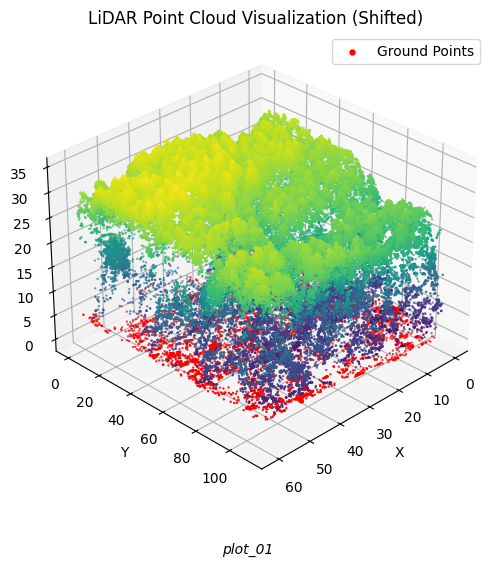

In [15]:
plot_shifted_lidar(plot_las_files[0])


Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


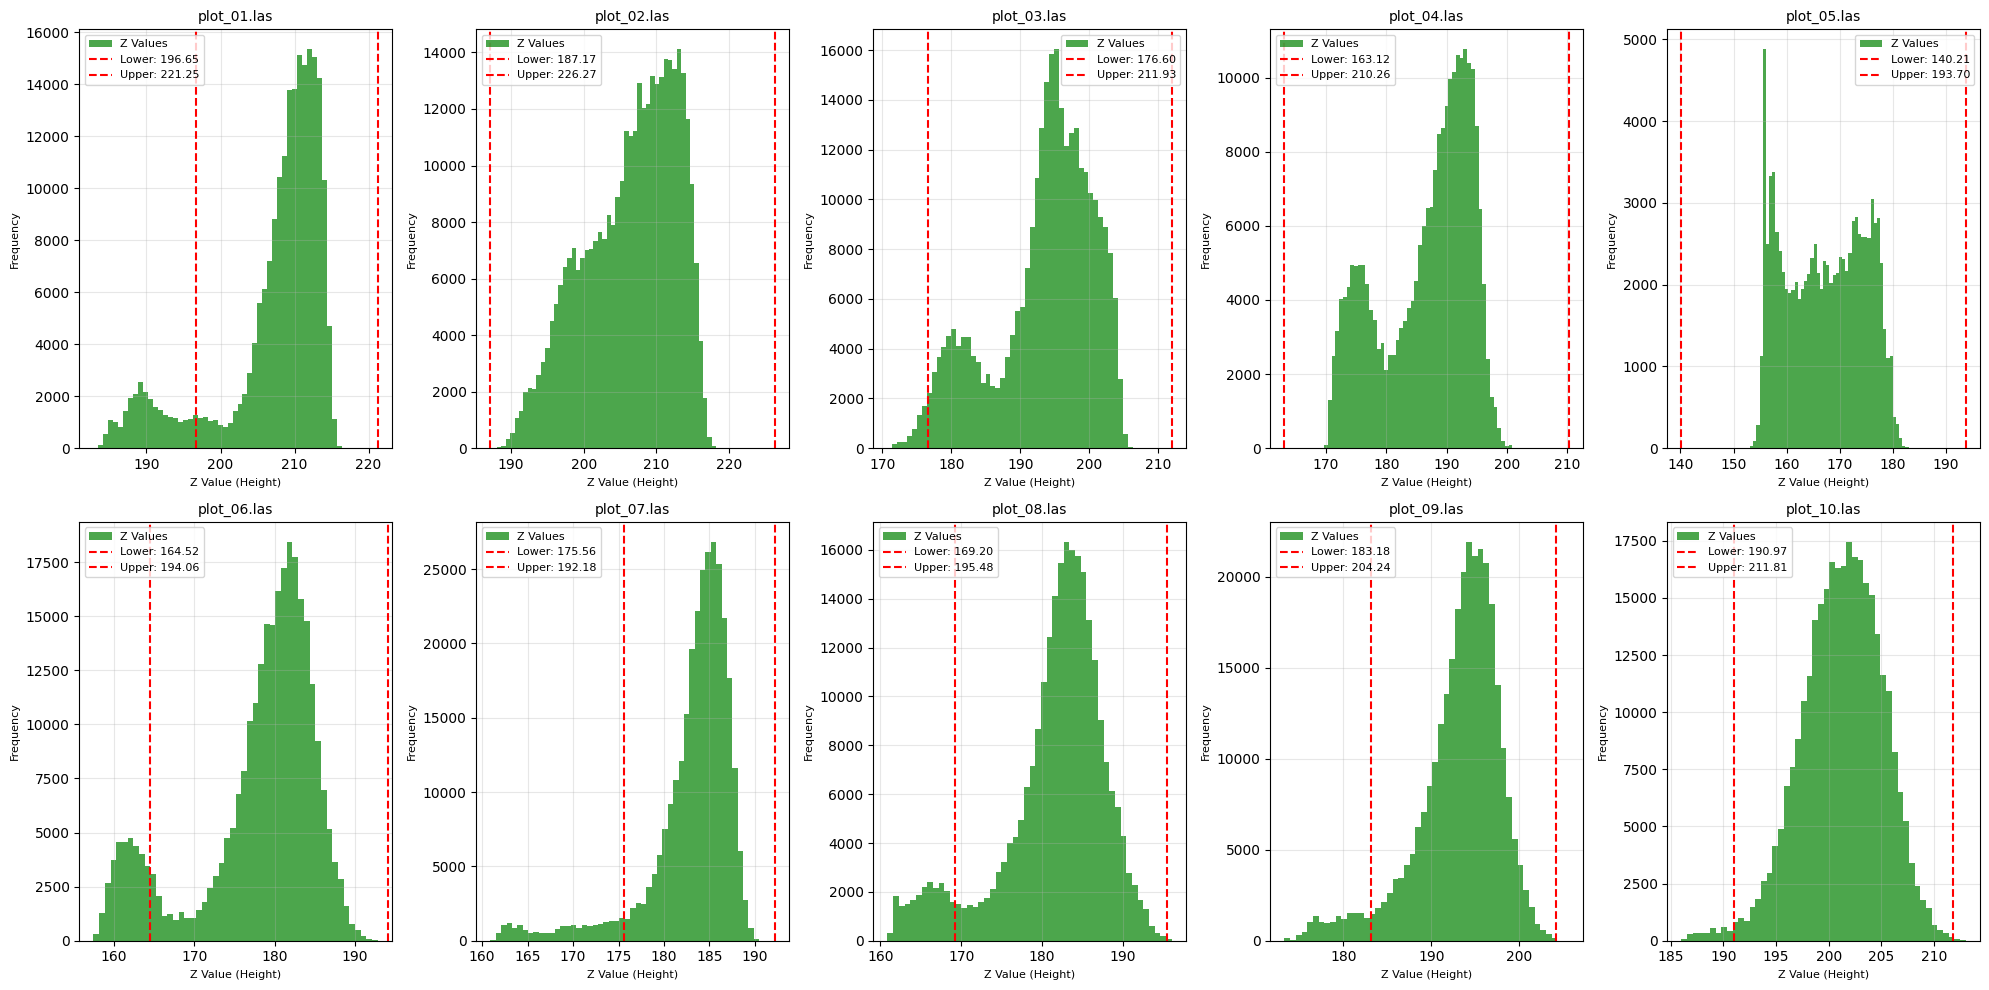

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, file_path in enumerate(plot_las_files[:10]):
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")

    # Load and filter points
    points = load_and_filter_las(file_path, filter_class=5)
    if points is None or len(points) == 0:
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue

    plot_z_distribution(points, axes[i], file_name)


plt.tight_layout()
plt.show()

In [17]:
preprocessed_data = []

for file_path in plot_las_files:

    points = load_and_filter_las(file_path, filter_class=5)

    if points is not None and len(points) > 0:
        preprocessed_points = preprocess_data(points)
        preprocessed_data.append(preprocessed_points)

    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")


File 1: 187731 preprocessed points
File 2: 350098 preprocessed points
File 3: 290624 preprocessed points
File 4: 241722 preprocessed points
File 5: 98878 preprocessed points
File 6: 255332 preprocessed points
File 7: 283645 preprocessed points
File 8: 234435 preprocessed points
File 9: 287341 preprocessed points
File 10: 307393 preprocessed points


In [18]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)

In [19]:
field_survey_gpd = gpd.read_file("data/field_survey.geojson")


In [30]:
field_survey_gpd

,plot,tree_no,species,d1,d2,dbh,age,height,angle,comment,geometry
0,1.0,1.0,Birch,47.2,46.2,46.70,NaN,26.5,0.0,None,POINT (547075.84 6450425.243)
1,1.0,2.0,Aspen,27.9,29.1,28.50,NaN,NaN,0.0,None,POINT (547074.299 6450419.542)
2,1.0,3.0,Fir,12.1,13.0,12.55,NaN,NaN,0.0,None,POINT (547077.454 6450419.994)
3,1.0,4.0,Aspen,23.3,23.7,23.50,69.0,27.4,0.0,None,POINT (547078.211 6450419.02)
4,1.0,5.0,Aspen,23.2,31.3,27.25,NaN,NaN,0.0,None,POINT (547074.669 6450415.573)
...,...,...,...,...,...,...,...,...,...,...,...
3597,10.0,522.0,Fir,10.0,9.3,9.65,NaN,NaN,0.0,None,POINT (546598.563 6449083.925)
3598,10.0,523.0,Tilia,19.6,21.0,20.30,NaN,NaN,0.0,Two tops,POINT (546594.681 6449079.402)
3599,10.0,524.0,Fir,22.8,24.7,23.75,NaN,NaN,0.0,None,POINT (546576.237 6449102.09)
3600,10.0,525.0,Birch,23.3,23.1,23.20,NaN,NaN,0.0,None,POINT (546600.707 6449170.22)


In [20]:
window_size = 3  # Radius for neighbor search
height_threshold = 2  # Minimum height to consider

local_maxima_data = []

for i, points in enumerate(preprocessed_data):
    print(f"Processing training file {i + 1} with {len(points)} points...")
    local_maxima_points = local_maxima_filter(points, window_size, height_threshold)
    print(f"Detected {len(local_maxima_points)} local maxima in training file {i + 1}.")

    local_maxima_data.append(local_maxima_points)

Processing training file 1 with 187731 points...
Detected 243 local maxima in training file 1.
Processing training file 2 with 350098 points...
Detected 178 local maxima in training file 2.
Processing training file 3 with 290624 points...
Detected 255 local maxima in training file 3.
Processing training file 4 with 241722 points...
Detected 207 local maxima in training file 4.
Processing training file 5 with 98878 points...
Detected 241 local maxima in training file 5.
Processing training file 6 with 255332 points...
Detected 270 local maxima in training file 6.
Processing training file 7 with 283645 points...
Detected 157 local maxima in training file 7.
Processing training file 8 with 234435 points...
Detected 222 local maxima in training file 8.
Processing training file 9 with 287341 points...
Detected 181 local maxima in training file 9.
Processing training file 10 with 307393 points...
Detected 166 local maxima in training file 10.


In [21]:
# Thresholds for matching
max_distance = 5.0
max_height_diff = 3.0

results_list = []

for i, local_maxima_points in enumerate(local_maxima_data, start=1):

    plot_number = i

    subset_gdf = field_survey_gpd[field_survey_gpd["plot"] == plot_number].copy()
    if subset_gdf.empty:
        print(f"No ground truth for plot {plot_number}. Skipping.")
        continue

    subset_gdf["x"] = subset_gdf.geometry.x
    subset_gdf["y"] = subset_gdf.geometry.y

    ground_truth_arr = subset_gdf[["x", "y", "height"]].to_numpy(dtype=float)

    # Match candidates (local maxima) to ground truth
    matches = match_candidates(
        ground_truth=ground_truth_arr,
        candidates=local_maxima_points,
        max_distance=max_distance,
        max_height_difference=max_height_diff
    )

    metrics_series = calculate_match_metrics(matches)
    metrics_series["plot"] = plot_number

    results_list.append(metrics_series)

    print(f"Plot {plot_number} => {metrics_series.to_dict()}")

results_df = pd.DataFrame(results_list).set_index("plot")

Plot 1 => {'precision': 0.593, 'recall': 0.343, 'f1': 0.434, 'avg_dist': 0.988, 'plot': 1.0}
Plot 2 => {'precision': 0.489, 'recall': 0.238, 'f1': 0.32, 'avg_dist': 1.542, 'plot': 2.0}
Plot 3 => {'precision': 0.404, 'recall': 0.31, 'f1': 0.351, 'avg_dist': 1.42, 'plot': 3.0}
Plot 4 => {'precision': 0.396, 'recall': 0.314, 'f1': 0.35, 'avg_dist': 1.71, 'plot': 4.0}
Plot 5 => {'precision': 0.32, 'recall': 0.37, 'f1': 0.343, 'avg_dist': 1.409, 'plot': 5.0}
Plot 6 => {'precision': 0.426, 'recall': 0.397, 'f1': 0.411, 'avg_dist': 1.099, 'plot': 6.0}
Plot 7 => {'precision': 0.611, 'recall': 0.235, 'f1': 0.34, 'avg_dist': 1.369, 'plot': 7.0}
Plot 8 => {'precision': 0.514, 'recall': 0.334, 'f1': 0.405, 'avg_dist': 1.219, 'plot': 8.0}
Plot 9 => {'precision': 0.564, 'recall': 0.222, 'f1': 0.319, 'avg_dist': 1.126, 'plot': 9.0}
Plot 10 => {'precision': 0.62, 'recall': 0.199, 'f1': 0.301, 'avg_dist': 1.178, 'plot': 10.0}


In [22]:
print("\nFinal per-plot metrics:")
print(results_df)

print("\nAverage metrics across all plots:")
print(results_df.mean(numeric_only=True))



Final per-plot metrics:
      precision  recall     f1  avg_dist
plot                                    
1.0       0.593   0.343  0.434     0.988
2.0       0.489   0.238  0.320     1.542
3.0       0.404   0.310  0.351     1.420
4.0       0.396   0.314  0.350     1.710
5.0       0.320   0.370  0.343     1.409
6.0       0.426   0.397  0.411     1.099
7.0       0.611   0.235  0.340     1.369
8.0       0.514   0.334  0.405     1.219
9.0       0.564   0.222  0.319     1.126
10.0      0.620   0.199  0.301     1.178

Average metrics across all plots:
precision    0.4937
recall       0.2962
f1           0.3574
avg_dist     1.3060
dtype: float64


In [23]:
import numpy as np

def points_to_voxel_grid(points, voxel_size):
    # Calculate the grid bounds
    x_min, y_min, z_min = np.min(points, axis=0)
    x_max, y_max, z_max = np.max(points, axis=0)

    # Compute grid dimensions
    x_range = int((x_max - x_min) / voxel_size) + 1
    y_range = int((y_max - y_min) / voxel_size) + 1
    z_range = int((z_max - z_min) / voxel_size) + 1

    # Initialize the 3D grid
    voxel_grid = np.zeros((x_range, y_range, z_range), dtype=np.float32)

    # Assign points to voxels
    for point in points:
        x, y, z = point
        x_idx = int((x - x_min) / voxel_size)
        y_idx = int((y - y_min) / voxel_size)
        z_idx = int((z - z_min) / voxel_size)
        voxel_grid[x_idx, y_idx, z_idx] = 1  # Mark voxel as occupied (binary)

    return voxel_grid

# Example: Convert each preprocessed point cloud to voxel grid
voxel_size = 1.0  # Define voxel size (e.g., 1 meter)
voxelized_data = []

for points in preprocessed_data:
    voxel_grid = points_to_voxel_grid(points, voxel_size)
    voxelized_data.append(voxel_grid)

# Print voxelized data info
for i, voxel_grid in enumerate(voxelized_data):
    print(f"Voxelized Grid {i + 1}: Shape {voxel_grid.shape}")

Voxelized Grid 1: Shape (62, 111, 20)
Voxelized Grid 2: Shape (130, 105, 31)
Voxelized Grid 3: Shape (130, 109, 30)
Voxelized Grid 4: Shape (89, 126, 32)
Voxelized Grid 5: Shape (127, 117, 30)
Voxelized Grid 6: Shape (115, 129, 29)
Voxelized Grid 7: Shape (115, 131, 15)
Voxelized Grid 8: Shape (109, 131, 27)
Voxelized Grid 9: Shape (104, 130, 22)
Voxelized Grid 10: Shape (102, 129, 21)


In [24]:
train_voxel_grids, test_voxel_grids = split_dataset(voxelized_data, train_ratio)


In [198]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Define the 3D CNN model
class TreeTop3DCNN(nn.Module):
    def __init__(self):
        super(TreeTop3DCNN, self).__init__()

        # First 3D convolution layer
        self.conv1 = nn.Conv3d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)

        # Second 3D convolution layer
        self.conv2 = nn.Conv3d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)

        # Third 3D convolution layer
        self.conv3 = nn.Conv3d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool3d(kernel_size=2, stride=2)

        # Dummy forward pass to determine the size for fc1
        dummy_input = torch.randn(1, 1, 130, 131, 32)  # Example input
        self.flattened_size = self._get_conv_output(dummy_input)

        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 3)  # Regression output layer

    def _get_conv_output(self, x):
        """Get the output size after passing through the convolution layers."""
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = torch.flatten(x, start_dim=1)
        return x.size(1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = torch.flatten(x, start_dim=1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [199]:
def pad_voxel_grid(grid, target_shape):
    """
    Pads the voxel grid to match the target shape.
    """
    # Calculate the necessary padding for each dimension
    pad_d = target_shape[0] - grid.shape[0]
    pad_h = target_shape[1] - grid.shape[1]
    pad_w = target_shape[2] - grid.shape[2]

    # Apply padding if needed
    pad = (0, pad_w, 0, pad_h, 0, pad_d)  # Padding format: (pad_left, pad_right, pad_top, pad_bottom, pad_front, pad_back)

    # Return the padded grid
    return np.pad(grid, pad, mode='constant', constant_values=0)

In [200]:
def split_dataset(voxel_grids, train_ratio):
    split_idx = int(len(voxel_grids) * train_ratio)
    train_data = voxel_grids[:split_idx]
    test_data = voxel_grids[split_idx:]
    return train_data, test_data


In [201]:
# Dataset Class for Voxel Grids and Labels
class VoxelDataset(Dataset):
    def __init__(self, voxel_grids, labels):
        self.voxel_grids = voxel_grids
        self.labels = labels

    def __len__(self):
        return len(self.voxel_grids)

    def __getitem__(self, idx):
        voxel_grid = self.voxel_grids[idx]
        label = self.labels[idx]
        voxel_grid = torch.tensor(voxel_grid, dtype=torch.float32).unsqueeze(0)  # Add channel dimension
        label = torch.tensor(label, dtype=torch.float32)
        return voxel_grid, label

In [202]:
tree_min = field_survey_gpd[['x', 'y', 'z']].min().values
tree_max = field_survey_gpd[['x', 'y', 'z']].max().values

In [203]:
field_survey_gpd['z'].fillna(0, inplace=True)  # Replace NaN in 'z' with 0


<ipython-input-203-ad34f32c755e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  field_survey_gpd['z'].fillna(0, inplace=True)  # Replace NaN in 'z' with 0


In [104]:
def transform_tree_to_voxel_space(tree_coords, tree_min, tree_max, voxel_min, voxel_max):
    # Perform transformation logic here
    transformed_coords = (tree_coords - tree_min) / (tree_max - tree_min) * (voxel_max - voxel_min) + voxel_min

    print(f"Original tree coordinates: {tree_coords}")
    print(f"Transformed tree coordinates: {transformed_coords}")
    return transformed_coords

In [204]:
def generate_labels(voxel_grids, field_survey_gpd, threshold_distance=1.0):
    labels = []
    for grid in voxel_grids:
        # Assuming each voxel grid is a 3D numpy array with shape (D, H, W)
        D, H, W = grid.shape
        # Voxel center
        voxel_center = np.array([D / 2, H / 2, W / 2])  # Center of voxel grid (in voxel space)

        closest_tree = None
        min_distance = float('inf')

        for _, row in field_survey_gpd.iterrows():
            tree_coords = np.array([row['x'], row['y'], row['z']])  # x, y, z coordinates of tree

            # Calculate distance between voxel center and tree coordinates
            distance = np.linalg.norm(voxel_center - tree_coords)

            if distance < min_distance:
                min_distance = distance
                closest_tree = tree_coords

        # Assign label based on proximity to tree
        if min_distance <= threshold_distance:
            labels.append(closest_tree)  # For regression task, use 3D coordinates
        else:
            labels.append([0, 0, 0])  # No tree detected, can be used for binary classification

    return labels





In [205]:
# Find the largest shape among the voxel grids
max_shape = [0, 0, 0]
for grid in voxelized_data:
    max_shape = [max(max_shape[i], grid.shape[i]) for i in range(3)]

# Add 1 for the channel dimension (in_channels=1)
max_shape = [1] + max_shape
print(f"Target shape for padding: {max_shape}")


Target shape for padding: [1, 130, 131, 32]


In [206]:
def pad_voxel_grid(grid, max_shape):
    # Calculate the necessary padding for each dimension
    pad_width = [(0, max_dim - grid.shape[i]) for i, max_dim in enumerate(max_shape)]

    # Pad the grid with zeros (you could also use another value)
    padded_grid = np.pad(grid, pad_width, mode='constant', constant_values=0)

    return padded_grid

# Assuming `max_shape` is the maximum shape of all grids
max_shape = (130, 131, 32)  # Example; adjust this based on your voxel grid sizes

# Apply padding to each voxel grid
padded_voxel_grids = []
for grid in voxelized_data:
    padded_grid = pad_voxel_grid(grid, max_shape)
    padded_voxel_grids.append(padded_grid)

In [207]:
train_ratio = 0.8
train_voxel_grids, test_voxel_grids = split_dataset(padded_voxel_grids, train_ratio)

# Re-generate labels as needed
train_labels = generate_labels(train_voxel_grids, field_survey_gpd)
test_labels = generate_labels(test_voxel_grids, field_survey_gpd)

# Create dataset and dataloader
train_dataset = VoxelDataset(train_voxel_grids, train_labels)
test_dataset = VoxelDataset(test_voxel_grids, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [208]:
np.unique(train_voxel_grids)

array([0., 1.], dtype=float32)

In [209]:
unique_values = np.unique(train_labels)
print("Unique values in train_labels:", unique_values)

Unique values in train_labels: [0]


In [193]:
train_labels

[1, 1, 1, 1, 1, 1, 1, 1]

In [194]:
test_labels

[1, 1]

In [210]:
model = TreeTop3DCNN()
criterion = nn.MSELoss()  # Use MSELoss for regression tasks
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [211]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for voxel_grids, labels in train_loader:
        optimizer.zero_grad()

        # Forward pass
        outputs = model(voxel_grids)  # Shape [batch_size, num_classes]

        # Compute loss
        loss = criterion(outputs, labels)  # Labels: shape [batch_size]

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader)}")


Epoch 1/10, Loss: 0.00395567249506712
Epoch 2/10, Loss: 14.827462196350098
Epoch 3/10, Loss: 0.04970736801624298
Epoch 4/10, Loss: 0.0197017639875412
Epoch 5/10, Loss: 0.006161077413707972
Epoch 6/10, Loss: 0.002721338300034404
Epoch 7/10, Loss: 0.00120007514487952
Epoch 8/10, Loss: 5.8628942497307435e-05
Epoch 9/10, Loss: 0.0007207269663922489
Epoch 10/10, Loss: 7.415840809699148e-05


In [212]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def compute_precision_recall_f1(predictions, ground_truth, threshold=0.8):
    """
    Compute precision, recall, and F1 score based on the threshold.
    """
    predicted_trees = (predictions > threshold).astype(int)
    true_trees = (ground_truth > 0).astype(int)  # Assuming ground_truth is binary (1 for tree, 0 for no tree)

    precision = precision_score(true_trees.flatten(), predicted_trees.flatten())
    recall = recall_score(true_trees.flatten(), predicted_trees.flatten())
    f1 = f1_score(true_trees.flatten(), predicted_trees.flatten())

    return precision, recall, f1

def compute_distance_error(predictions, ground_truth, threshold=0.5):
    """
    Compute the average distance error between predicted and ground truth tree locations.
    """
    predicted_trees = np.argwhere(predictions > threshold)  # Find predicted tree coordinates
    true_trees = np.argwhere(ground_truth > 0)  # Find ground truth tree coordinates

    total_distance = 0
    count = 0

    for pred_tree in predicted_trees:
        distances = np.linalg.norm(true_trees - pred_tree, axis=1)
        if len(distances) > 0:
            min_distance = np.min(distances)
            total_distance += min_distance
            count += 1

    return total_distance / count if count > 0 else 0

# After training, evaluate the model using the metrics
model.eval()  # Set model to evaluation mode
test_loss = 0.0
precision_all = []
recall_all = []
f1_all = []
distance_errors = []

with torch.no_grad():
    for voxel_grids, labels in test_loader:
        outputs = model(voxel_grids)

        # Assume the labels are ground truth for trees (e.g., binary grid indicating tree presence)
        # Apply a threshold to the outputs
        predicted_voxel_grids = outputs.numpy()
        ground_truth_voxel_grids = labels.numpy()

        # Compute Precision, Recall, F1-Score
        precision, recall, f1 = compute_precision_recall_f1(predicted_voxel_grids, ground_truth_voxel_grids)
        precision_all.append(precision)
        recall_all.append(recall)
        f1_all.append(f1)

        # Compute Distance Error
        distance_error = compute_distance_error(predicted_voxel_grids, ground_truth_voxel_grids)
        distance_errors.append(distance_error)

        # Compute loss (optional)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

# Calculate average metrics
average_precision = np.mean(precision_all)
average_recall = np.mean(recall_all)
average_f1 = np.mean(f1_all)
average_distance_error = np.mean(distance_errors)

print(f"Test Loss: {test_loss / len(test_loader)}")
print(f"Average Precision: {average_precision}")
print(f"Average Recall: {average_recall}")
print(f"Average F1-Score: {average_f1}")
print(f"Average Distance Error: {average_distance_error}")




Test Loss: 0.0003311819164082408
Average Precision: 0.0
Average Recall: 0.0
Average F1-Score: 0.0
Average Distance Error: 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
print(f"Predicted voxel grids: {predicted_voxel_grids}")


Predicted voxel grids: [[ 0.0095555   0.01840181 -0.01162317]
 [ 0.00810593  0.01959276 -0.01242363]]


In [119]:
print("Predicted voxel grids:", predicted_voxel_grids)
print("Ground truth voxel grids:", ground_truth_voxel_grids)

Predicted voxel grids: [[36.688335 41.297073 16.751781]
 [35.961514 40.47175  16.405998]]
Ground truth voxel grids: [[41.574932 53.283268 23.578947]
 [41.574932 53.283268 23.578947]]


In [71]:
print("Predicted voxel grids min/max:", np.min(predicted_voxel_grids), np.max(predicted_voxel_grids))


Predicted voxel grids min/max: -0.012423627 0.019592762


In [72]:
print("Ground truth values:", ground_truth_voxel_grids)


Ground truth values: [[0. 0. 0.]
 [0. 0. 0.]]


In [75]:
print("Sample of ground truth labels:")
print(ground_truth_voxel_grids[:5])  # Show the first 5 entries, adjust if needed

# Check the unique values in the ground truth to ensure it contains both 0 and 1
print("Unique values in ground truth labels:", np.unique(ground_truth_voxel_grids))

Sample of ground truth labels:
[[0. 0. 0.]
 [0. 0. 0.]]
Unique values in ground truth labels: [0.]
